# 🌍 DEL 2: Regionalna Analiza Spotify Top-50

## Glavni cilj: Odgovoriti na RV6

| Koda | Raziskovalno Vprašanje |
|------|------------------------|
| **RV6** | **Kako se globalni trendi razlikujejo od lokalnih trendov v različnih državah?** |

### Podhipoteze:
- **RV6a:** Ali obstajajo skladbe, ki so uspešne samo v določenih regijah?
- **RV6b:** Kako se zvočne značilnosti Top-50 skladb razlikujejo med državami?
- **RV6c:** Ali različne kulture preferirajo različne glasbene karakteristike?
- **RV6d:** Kateri izvajalci dominirajo globalno vs. lokalno?

### Podatki:
- Top-50 seznami iz 10 držav/regij
- Države: USA, UK, France, Spain, Italy, Japan, South Korea, Mexico, Argentina, Global

---

In [1]:
# =====================================================
# 1. UVOZ KNJIŽNIC IN NASTAVITVE
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plotly za interaktivne grafe
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Nastavitve vizualizacije
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_palette("husl")

print("✅ Knjižnice uvožene!")

✅ Knjižnice uvožene!


In [2]:
# =====================================================
# 2. NALAGANJE PODATKOV PO DRŽAVAH
# =====================================================

print("📁 NALAGANJE TOP-50 PODATKOV PO DRŽAVAH")
print("=" * 60)

# Definicija držav in datotek
country_files = {
    'USA': '../data/spotify-streaming-top-50-usa.csv',
    'UK': '../data/spotify-streaming-top-50-uk.csv',
    'France': '../data/spotify-streaming-top-50-france.csv',
    'Spain': '../data/spotify-streaming-top-50-spain.csv',
    'Italy': '../data/spotify-streaming-top-50-italy.csv',
    'Japan': '../data/spotify-streaming-top-50-japan.csv',
    'South Korea': '../data/spotify-streaming-top-50-south-korea.csv',
    'Mexico': '../data/spotify-streaming-top-50-mexico.csv',
    'Argentina': '../data/spotify-streaming-top-50-argentina.csv',
    'Global': '../data/spotify-streaming-top-50-world.csv'
}

# Naloži vse datasete
country_data = {}
for country, filepath in country_files.items():
    try:
        df = pd.read_csv(filepath)
        df['country'] = country
        country_data[country] = df
        print(f"✅ {country:15} | {len(df):,} vrstic | {df['date'].nunique()} dni")
    except FileNotFoundError:
        print(f"❌ {country:15} | Datoteka ne obstaja")

# Združi vse podatke
df_all = pd.concat(country_data.values(), ignore_index=True)

print(f"\n📊 SKUPAJ: {len(df_all):,} vrstic iz {len(country_data)} držav")
print(f"   Unikatnih skladb: {df_all['song'].nunique():,}")
print(f"   Unikatnih izvajalcev: {df_all['artist'].nunique():,}")
print(f"   Časovno obdobje: {df_all['date'].min()} - {df_all['date'].max()}")

📁 NALAGANJE TOP-50 PODATKOV PO DRŽAVAH
✅ USA             | 27,800 vrstic | 556 dni
✅ UK              | 27,800 vrstic | 556 dni
✅ France          | 27,800 vrstic | 556 dni
✅ Spain           | 27,800 vrstic | 556 dni
✅ Italy           | 27,800 vrstic | 556 dni
✅ Japan           | 27,800 vrstic | 556 dni
✅ South Korea     | 27,800 vrstic | 556 dni
✅ Mexico          | 27,800 vrstic | 556 dni
✅ Argentina       | 27,800 vrstic | 556 dni
✅ Global          | 27,800 vrstic | 556 dni

📊 SKUPAJ: 278,000 vrstic iz 10 držav
   Unikatnih skladb: 4,088
   Unikatnih izvajalcev: 1,651
   Časovno obdobje: 2023-05-18 - 2024-11-27


In [3]:
# =====================================================
# 3. PREGLED PODATKOV IN ČIŠČENJE
# =====================================================

print("🔍 PREGLED STRUKTURE PODATKOV")
print("=" * 60)

# Stolpci
print(f"\n📋 Stolpci: {list(df_all.columns)}")

# Pretvorba datuma
df_all['date'] = pd.to_datetime(df_all['date'])
df_all['year'] = df_all['date'].dt.year
df_all['month'] = df_all['date'].dt.month
df_all['week'] = df_all['date'].dt.isocalendar().week

# Pretvorba trajanja v minute
df_all['duration_min'] = df_all['duration_ms'] / 60000

# Izloči ekstreme trajanja
df_all = df_all[(df_all['duration_min'] > 1) & (df_all['duration_min'] < 10)]

# Manjkajoče vrednosti
print(f"\n❓ Manjkajoče vrednosti:")
missing = df_all.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing)
else:
    print("   Ni manjkajočih vrednosti!")

# Statistike po državah
print(f"\n📊 STATISTIKE PO DRŽAVAH:")
print("-" * 60)
for country in country_data.keys():
    country_df = df_all[df_all['country'] == country]
    n_unique_songs = country_df['song'].nunique()
    n_unique_artists = country_df['artist'].nunique()
    avg_popularity = country_df['popularity'].mean()
    print(f"{country:15} | {n_unique_songs:4} skladb | {n_unique_artists:4} izvajalcev | Avg pop: {avg_popularity:.1f}")

🔍 PREGLED STRUKTURE PODATKOV

📋 Stolpci: ['date', 'position', 'song', 'artist', 'popularity', 'duration_ms', 'album_type', 'total_tracks', 'release_date', 'is_explicit', 'album_cover_url', 'country']

❓ Manjkajoče vrednosti:
   Ni manjkajočih vrednosti!

📊 STATISTIKE PO DRŽAVAH:
------------------------------------------------------------
USA             |  936 skladb |  296 izvajalcev | Avg pop: 87.7
UK              |  798 skladb |  343 izvajalcev | Avg pop: 86.8
France          |  693 skladb |  324 izvajalcev | Avg pop: 76.7
Spain           |  545 skladb |  306 izvajalcev | Avg pop: 81.1
Italy           |  817 skladb |  291 izvajalcev | Avg pop: 73.6
Japan           |  248 skladb |  105 izvajalcev | Avg pop: 72.4
South Korea     |  526 skladb |  194 izvajalcev | Avg pop: 76.9
Mexico          |  449 skladb |  238 izvajalcev | Avg pop: 84.6
Argentina       |  391 skladb |  241 izvajalcev | Avg pop: 79.5
Global          |  790 skladb |  343 izvajalcev | Avg pop: 89.6


---

## 📊 SEKCIJA 1: RV6a – Globalni vs Lokalni Hiti

**Raziskovalno vprašanje:** *Ali obstajajo skladbe, ki so uspešne samo v določenih regijah?*

**Metoda:**
- Identifikacija skladb, ki se pojavijo v večini držav (globalni hiti)
- Identifikacija skladb, ki so uspešne samo v 1-2 državah (lokalni hiti)
- Statistična primerjava deležev

**Pričakovani odgovor:** Obstaja jasna delitev med globalnimi mega-hiti in lokalnimi favoriziranci.

In [4]:
# =====================================================
# 4.1 IDENTIFIKACIJA GLOBALNIH HITOV
# =====================================================

print("🌍 ANALIZA GLOBALNIH vs LOKALNIH HITOV")
print("=" * 60)

# Poišči skladbe, ki se pojavljajo v več državah
song_country_counts = df_all.groupby('song')['country'].nunique().reset_index()
song_country_counts.columns = ['song', 'n_countries']

# Kategorizacija
def categorize_reach(n):
    if n >= 8:
        return 'Globalni hit'
    elif n >= 5:
        return 'Mednarodni'
    elif n >= 3:
        return 'Regionalni'
    else:
        return 'Lokalni'

song_country_counts['reach'] = song_country_counts['n_countries'].apply(categorize_reach)

# Statistike
reach_counts = song_country_counts['reach'].value_counts()
print(f"\n📊 PORAZDELITEV DOSEGA SKLADB:")
print("-" * 40)
for reach, count in reach_counts.items():
    pct = count / len(song_country_counts) * 100
    bar = "█" * int(pct / 3)
    print(f"{reach:15} | {count:5} ({pct:5.1f}%) {bar}")

# Top globalni hiti
global_hits = song_country_counts[song_country_counts['n_countries'] >= 8].sort_values('n_countries', ascending=False)

print(f"\n🏆 TOP 15 GLOBALNIH HITOV (prisotni v 8+ državah):")
print("-" * 60)

# Pridobi dodatne info
for i, row in global_hits.head(15).iterrows():
    song = row['song']
    n_countries = row['n_countries']
    # Poišči izvajalca
    artist = df_all[df_all['song'] == song]['artist'].iloc[0]
    avg_pop = df_all[df_all['song'] == song]['popularity'].mean()
    print(f"{n_countries:2}🌍 | {song[:35]:35} | {artist[:25]:25} | Pop: {avg_pop:.0f}")

🌍 ANALIZA GLOBALNIH vs LOKALNIH HITOV

📊 PORAZDELITEV DOSEGA SKLADB:
----------------------------------------
Lokalni         |  3438 ( 84.3%) ████████████████████████████
Regionalni      |   507 ( 12.4%) ████
Mednarodni      |   112 (  2.7%) 
Globalni hit    |    20 (  0.5%) 

🏆 TOP 15 GLOBALNIH HITOV (prisotni v 8+ državah):
------------------------------------------------------------
 9🌍 | APT.                                | ROSÉ & Bruno Mars         | Pop: 95
 9🌍 | All I Want for Christmas Is You     | Mariah Carey              | Pop: 94
 9🌍 | Beautiful Things                    | Benson Boone              | Pop: 91
 9🌍 | CHIHIRO                             | Billie Eilish             | Pop: 91
 9🌍 | Last Christmas - Single Version     | Wham!                     | Pop: 82
 9🌍 | Cruel Summer                        | Taylor Swift              | Pop: 97
 9🌍 | Die With A Smile                    | Lady Gaga & Bruno Mars    | Pop: 98
 9🌍 | Fortnight (feat. Post Malone)       | Taylor

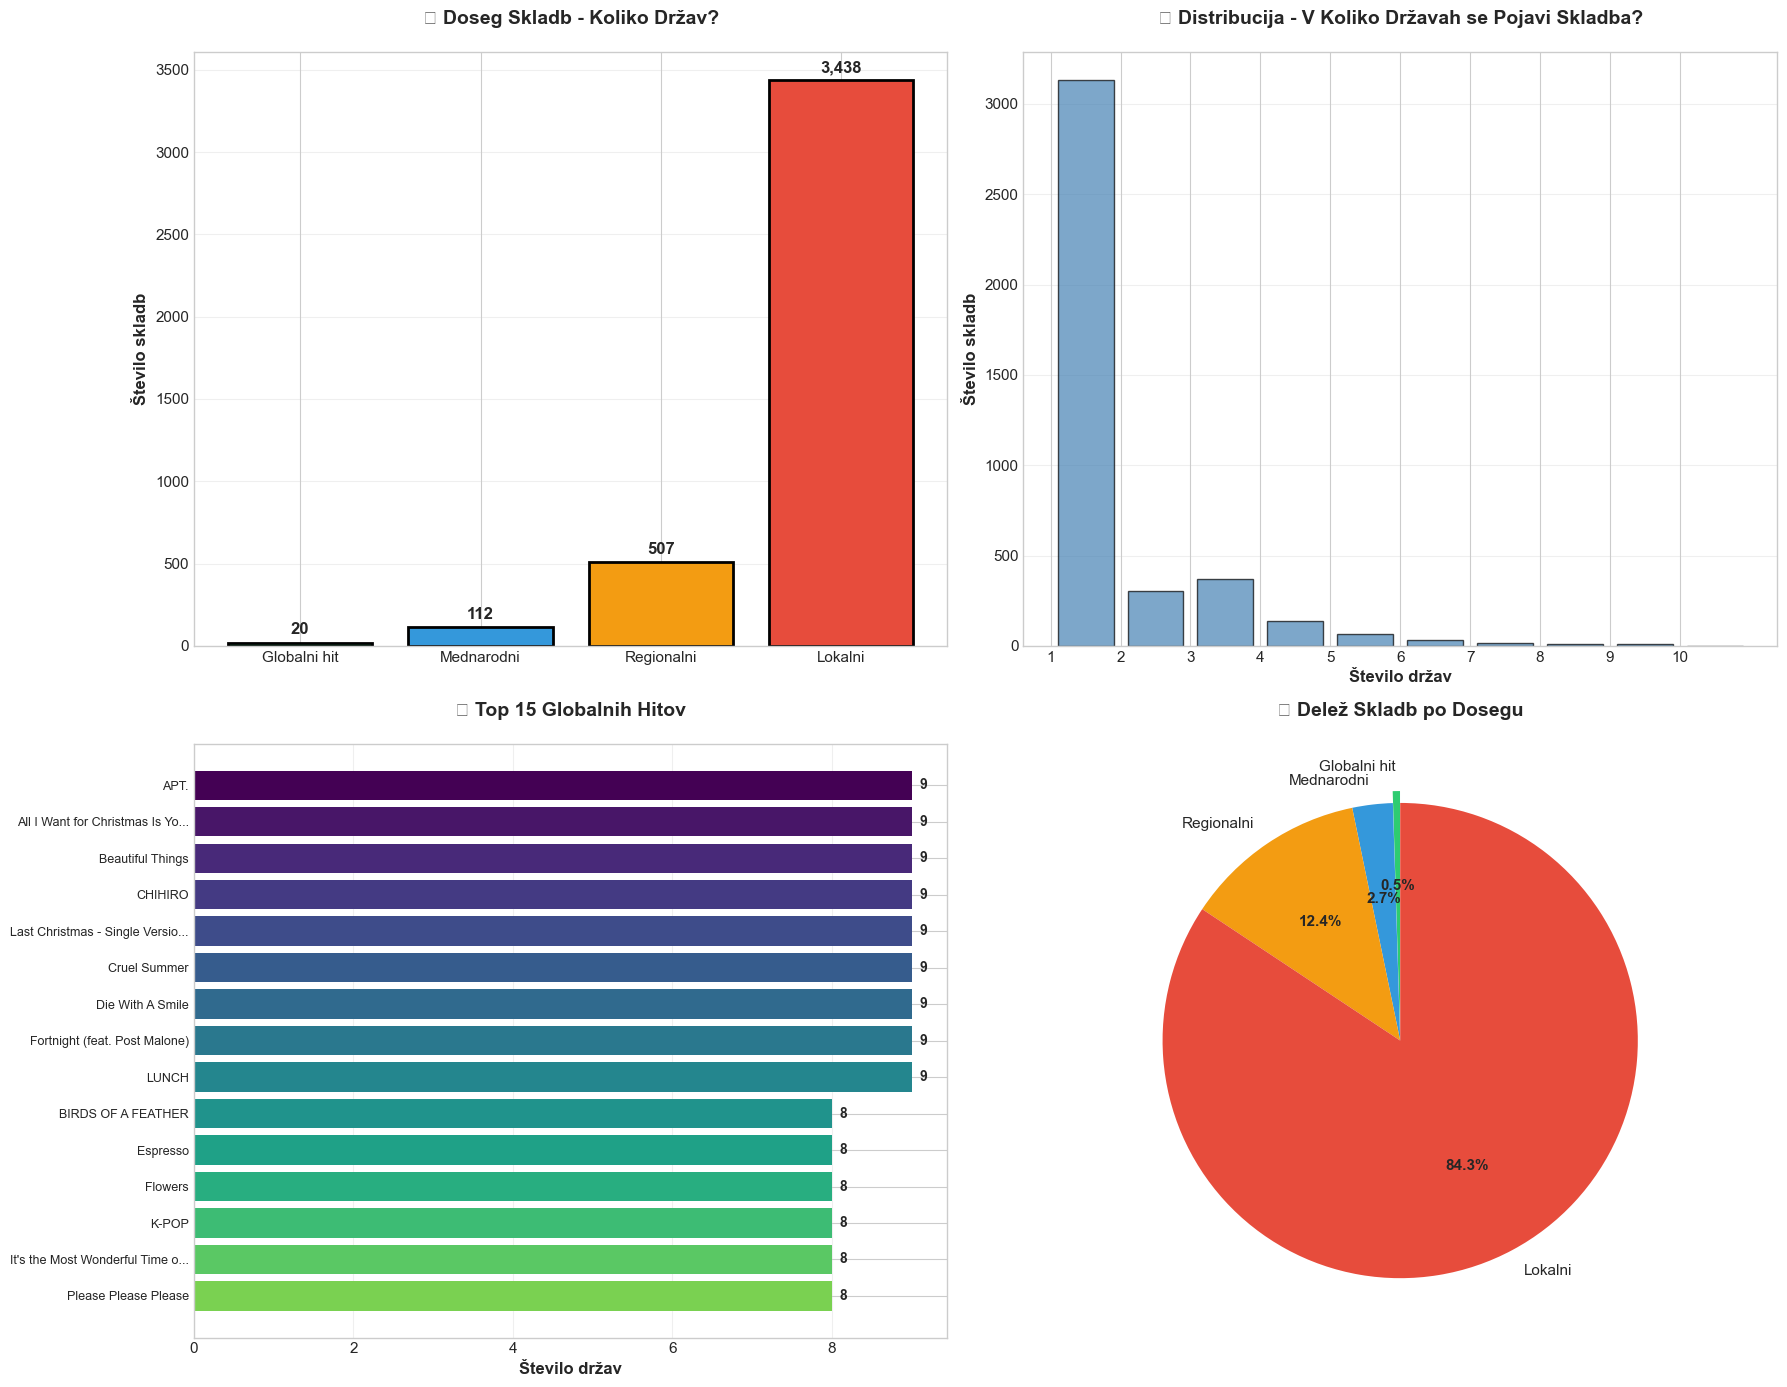


💡 Večina skladb je lokalna - le redke postanejo globalni hiti!


In [5]:
# =====================================================
# 4.2 VIZUALIZACIJA GLOBALNIH HITOV
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Porazdelitev dosega
ax1 = axes[0, 0]
reach_order = ['Globalni hit', 'Mednarodni', 'Regionalni', 'Lokalni']
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
reach_data = [reach_counts.get(r, 0) for r in reach_order]
bars = ax1.bar(reach_order, reach_data, color=colors, edgecolor='black', linewidth=2)
ax1.set_ylabel('Število skladb', fontsize=12, fontweight='bold')
ax1.set_title('🌍 Doseg Skladb - Koliko Držav?', fontsize=14, fontweight='bold', pad=20)
for bar, val in zip(bars, reach_data):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{val:,}', ha='center', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Histogram števila držav
ax2 = axes[0, 1]
ax2.hist(song_country_counts['n_countries'], bins=range(1, 12), 
         color='steelblue', edgecolor='black', alpha=0.7, rwidth=0.8)
ax2.set_xlabel('Število držav', fontsize=12, fontweight='bold')
ax2.set_ylabel('Število skladb', fontsize=12, fontweight='bold')
ax2.set_title('📊 Distribucija - V Koliko Državah se Pojavi Skladba?', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xticks(range(1, 11))
ax2.grid(axis='y', alpha=0.3)

# 3. Top 15 globalnih hitov
ax3 = axes[1, 0]
top15 = global_hits.head(15)
songs_short = [s[:30] + '...' if len(s) > 30 else s for s in top15['song'].values]
colors_bar = plt.cm.viridis(np.linspace(0, 0.8, 15))
ax3.barh(range(len(top15)), top15['n_countries'], color=colors_bar)
ax3.set_yticks(range(len(top15)))
ax3.set_yticklabels(songs_short, fontsize=9)
ax3.set_xlabel('Število držav', fontsize=12, fontweight='bold')
ax3.set_title('🏆 Top 15 Globalnih Hitov', fontsize=14, fontweight='bold', pad=20)
ax3.invert_yaxis()
for i, v in enumerate(top15['n_countries']):
    ax3.text(v + 0.1, i, str(v), va='center', fontsize=10, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 4. Pie chart dosega
ax4 = axes[1, 1]
wedges, texts, autotexts = ax4.pie(reach_data, labels=reach_order, 
                                   autopct='%1.1f%%', colors=colors,
                                   startangle=90, explode=[0.05, 0, 0, 0])
ax4.set_title('🎯 Delež Skladb po Dosegu', fontsize=14, fontweight='bold', pad=20)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

plt.tight_layout()
plt.savefig('../outputs/global_local_hits.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Večina skladb je lokalna - le redke postanejo globalni hiti!")

---

## 📊 SEKCIJA 2: RV6b – Primerjava popularnosti in eksplicitnosti med državami

**Raziskovalno vprašanje:** *Kako se metrike Top-50 skladb razlikujejo med državami?*

**Metoda:**
- Primerjava povprečne popularnosti po državah
- Analiza deleža eksplicitnih skladb (kulturne razlike)
- Box plot distribucij

**Pričakovani odgovor:** Določene države imajo višje povprečne ocene popularnosti; različne kulture imajo različno toleranco do eksplicitne vsebine.

📈 PRIMERJAVA POPULARNOSTI MED DRŽAVAMI
             avg_pop  std_pop  median_pop  n_songs  n_artists  avg_duration  explicit_pct
country                                                                                  
Global         89.63     9.96        91.0      790        343          3.28          40.0
USA            87.68    10.44        89.0      936        296          3.31          48.0
UK             86.80    10.32        89.0      798        343          3.29          32.0
Mexico         84.64     8.94        85.0      449        238          3.14          55.0
Spain          81.12    10.09        82.0      545        306          3.29          42.0
Argentina      79.51     9.27        79.0      391        241          3.03          32.0
South Korea    76.92    12.91        79.0      526        194          3.20          10.0
France         76.65    11.56        75.0      693        324          3.09          56.0
Italy          73.60    10.62        74.0      817        291

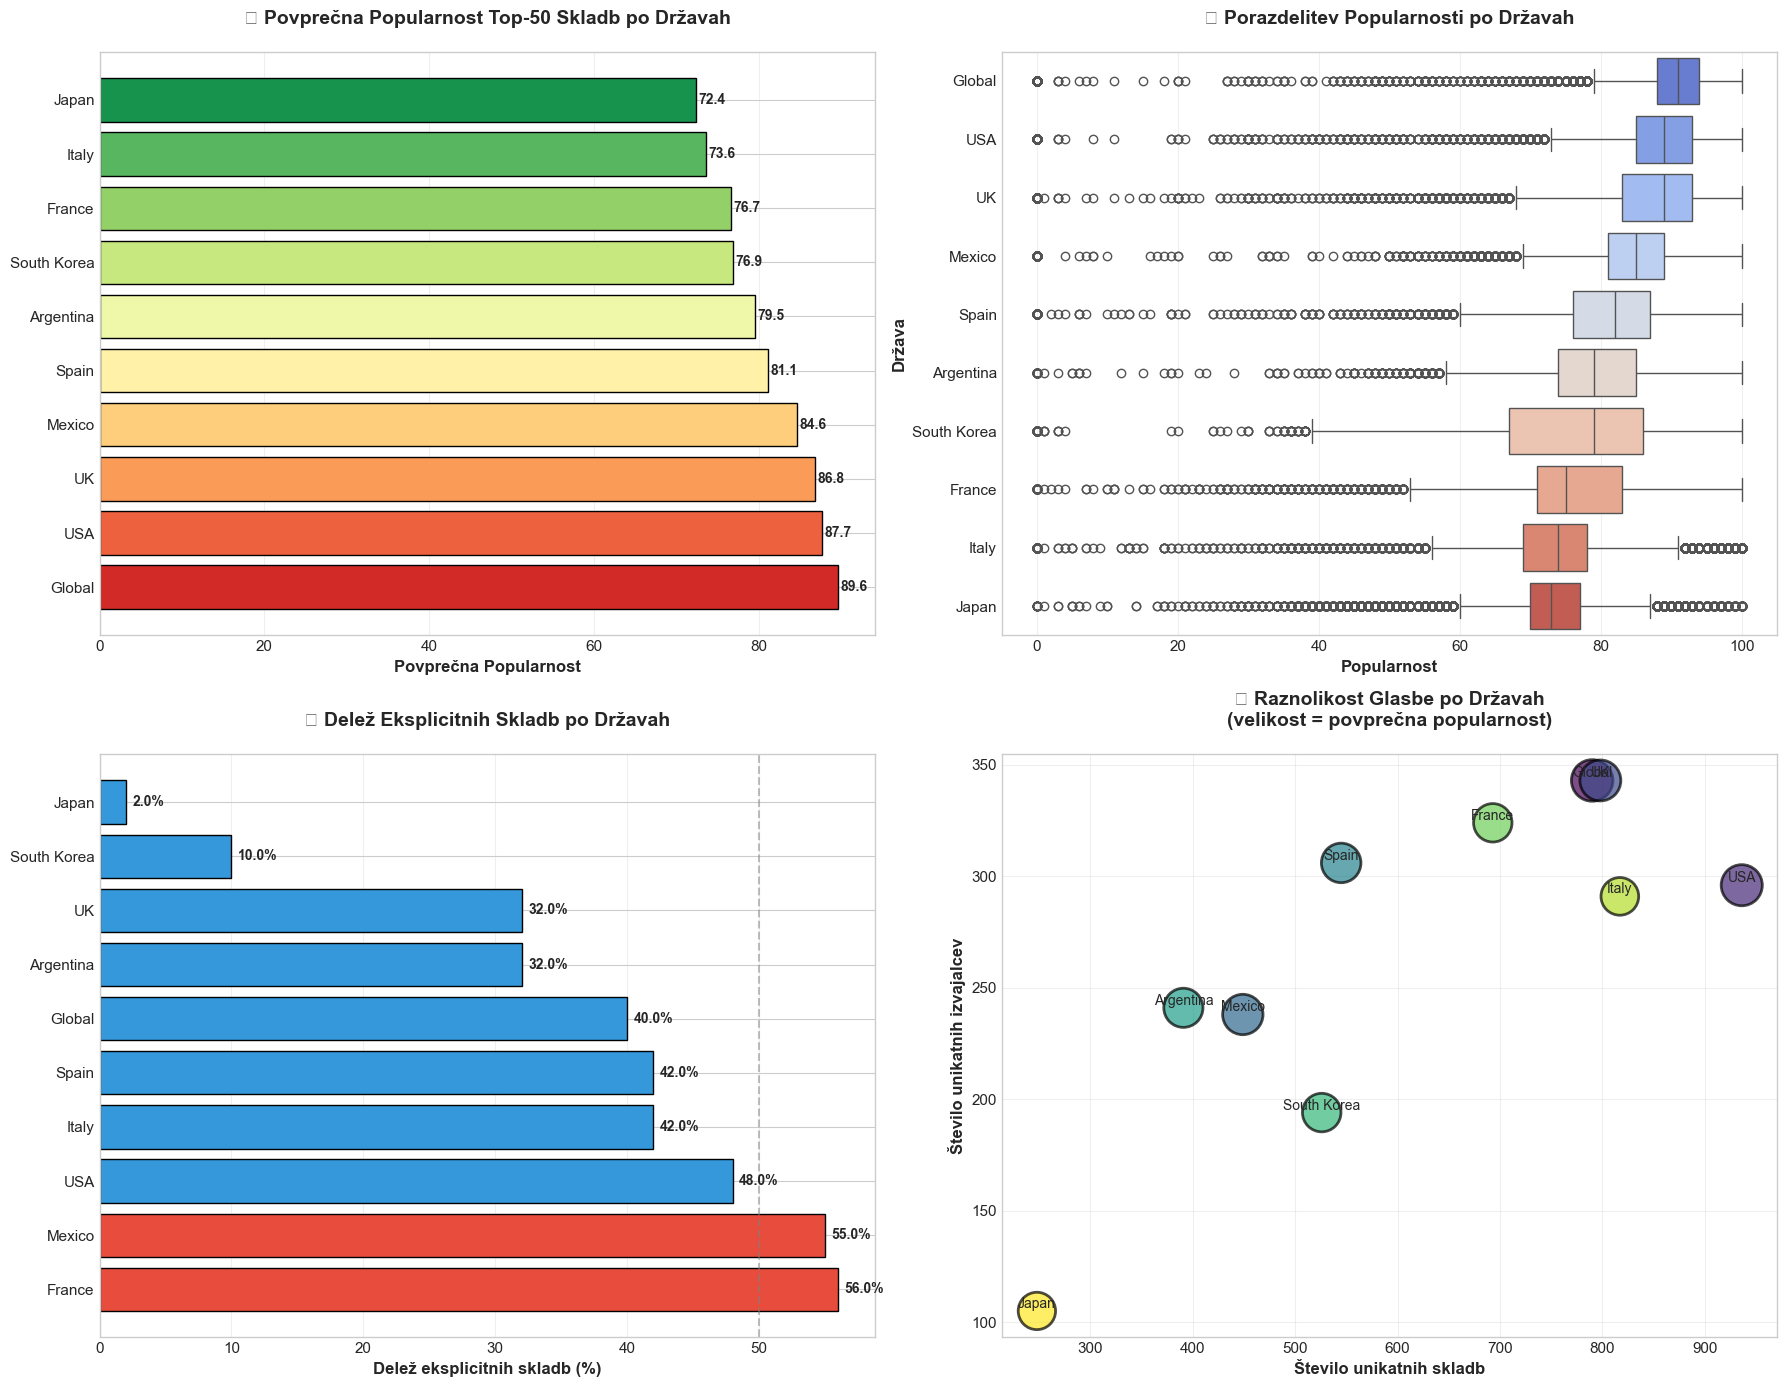

In [6]:
# =====================================================
# 5.1 POVPREČNA POPULARNOST PO DRŽAVAH
# =====================================================

print("📈 PRIMERJAVA POPULARNOSTI MED DRŽAVAMI")
print("=" * 60)

# Izračunaj statistike po državah
country_stats = df_all.groupby('country').agg({
    'popularity': ['mean', 'std', 'median'],
    'song': 'nunique',
    'artist': 'nunique',
    'duration_min': 'mean',
    'is_explicit': 'mean'
}).round(2)

country_stats.columns = ['avg_pop', 'std_pop', 'median_pop', 'n_songs', 'n_artists', 'avg_duration', 'explicit_pct']
country_stats['explicit_pct'] = (country_stats['explicit_pct'] * 100).round(1)
country_stats = country_stats.sort_values('avg_pop', ascending=False)

print(country_stats.to_string())

# Vizualizacija
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Povprečna popularnost
ax1 = axes[0, 0]
colors = sns.color_palette("RdYlGn", len(country_stats))
bars = ax1.barh(country_stats.index, country_stats['avg_pop'], color=colors, edgecolor='black')
ax1.set_xlabel('Povprečna Popularnost', fontsize=12, fontweight='bold')
ax1.set_title('📊 Povprečna Popularnost Top-50 Skladb po Državah', fontsize=14, fontweight='bold', pad=20)
for bar, val in zip(bars, country_stats['avg_pop']):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
             va='center', fontsize=10, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Box plot popularnosti
ax2 = axes[0, 1]
country_order = country_stats.index.tolist()
df_plot = df_all[df_all['country'].isin(country_order)].copy()
df_plot['country'] = pd.Categorical(df_plot['country'], categories=country_order, ordered=True)
sns.boxplot(data=df_plot, y='country', x='popularity', palette='coolwarm', ax=ax2)
ax2.set_xlabel('Popularnost', fontsize=12, fontweight='bold')
ax2.set_ylabel('Država', fontsize=12, fontweight='bold')
ax2.set_title('📦 Porazdelitev Popularnosti po Državah', fontsize=14, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.3)

# 3. Delež eksplicitnih skladb
ax3 = axes[1, 0]
explicit_sorted = country_stats.sort_values('explicit_pct', ascending=False)
colors_exp = ['#e74c3c' if x > 50 else '#3498db' for x in explicit_sorted['explicit_pct']]
bars = ax3.barh(explicit_sorted.index, explicit_sorted['explicit_pct'], color=colors_exp, edgecolor='black')
ax3.set_xlabel('Delež eksplicitnih skladb (%)', fontsize=12, fontweight='bold')
ax3.set_title('🔞 Delež Eksplicitnih Skladb po Državah', fontsize=14, fontweight='bold', pad=20)
ax3.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, explicit_sorted['explicit_pct']):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
             va='center', fontsize=10, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 4. Število unikatnih izvajalcev vs skladb
ax4 = axes[1, 1]
ax4.scatter(country_stats['n_songs'], country_stats['n_artists'], 
            s=country_stats['avg_pop']*10, alpha=0.7, 
            c=range(len(country_stats)), cmap='viridis', edgecolors='black', linewidth=2)
for i, country in enumerate(country_stats.index):
    ax4.annotate(country, (country_stats.loc[country, 'n_songs'], 
                          country_stats.loc[country, 'n_artists']),
                fontsize=10, ha='center', va='bottom')
ax4.set_xlabel('Število unikatnih skladb', fontsize=12, fontweight='bold')
ax4.set_ylabel('Število unikatnih izvajalcev', fontsize=12, fontweight='bold')
ax4.set_title('🎯 Raznolikost Glasbe po Državah\n(velikost = povprečna popularnost)', 
              fontsize=14, fontweight='bold', pad=20)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/country_popularity_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 📊 SEKCIJA 3: RV6d – Top izvajalci po državah

**Raziskovalno vprašanje:** *Kateri izvajalci dominirajo globalno vs. lokalno?*

**Metoda:**
- Identifikacija najpogostejših izvajalcev v Top-50 po državah
- Primerjava med državami (USA vs Japan vs Mexico vs UK)
- Globalni top 15 izvajalcev

**Pričakovani odgovor:** Nekateri izvajalci so globalno dominantni (angleškogovoreči), medtem ko imajo azijske in latinske države svoje lokalne zvezde.

In [7]:
# =====================================================
# 6.1 NAJPOGOSTEJŠI IZVAJALCI PO DRŽAVAH
# =====================================================

print("🎤 TOP IZVAJALCI PO DRŽAVAH")
print("=" * 60)

# Funkcija za top izvajalce
def get_top_artists(country_df, top_n=10):
    """Vrne top N izvajalcev po številu pojavitev v top 50"""
    artist_counts = country_df.groupby('artist').size().sort_values(ascending=False).head(top_n)
    return artist_counts

# Top 5 za vsako državo
top_artists_by_country = {}
for country in country_data.keys():
    country_df = df_all[df_all['country'] == country]
    top_artists_by_country[country] = get_top_artists(country_df, 5)

# Prikaz
for country, artists in top_artists_by_country.items():
    print(f"\n🏆 {country.upper()}:")
    print("-" * 40)
    for i, (artist, count) in enumerate(artists.items(), 1):
        print(f"   {i}. {artist[:35]:35} | {count:4} dni v Top 50")

# Globalni top izvajalci (čez vse države)
print(f"\n\n🌍 GLOBALNI TOP 15 IZVAJALCI (čez vse države):")
print("=" * 60)
global_artist_counts = df_all.groupby('artist').size().sort_values(ascending=False).head(15)
for i, (artist, count) in enumerate(global_artist_counts.items(), 1):
    # V koliko državah nastopa?
    n_countries = df_all[df_all['artist'] == artist]['country'].nunique()
    print(f"{i:2}. {artist[:35]:35} | {count:5} pojavitev | {n_countries:2} držav")

🎤 TOP IZVAJALCI PO DRŽAVAH

🏆 USA:
----------------------------------------
   1. Taylor Swift                        | 2016 dni v Top 50
   2. Zach Bryan                          | 1860 dni v Top 50
   3. Morgan Wallen                       | 1672 dni v Top 50
   4. Sabrina Carpenter                   |  968 dni v Top 50
   5. Drake                               |  844 dni v Top 50

🏆 UK:
----------------------------------------
   1. Taylor Swift                        | 2093 dni v Top 50
   2. Sabrina Carpenter                   |  965 dni v Top 50
   3. Billie Eilish                       |  819 dni v Top 50
   4. Olivia Rodrigo                      |  643 dni v Top 50
   5. Chappell Roan                       |  634 dni v Top 50

🏆 FRANCE:
----------------------------------------
   1. Werenoi                             | 2200 dni v Top 50
   2. PLK                                 |  905 dni v Top 50
   3. SDM                                 |  901 dni v Top 50
   4. Jul         

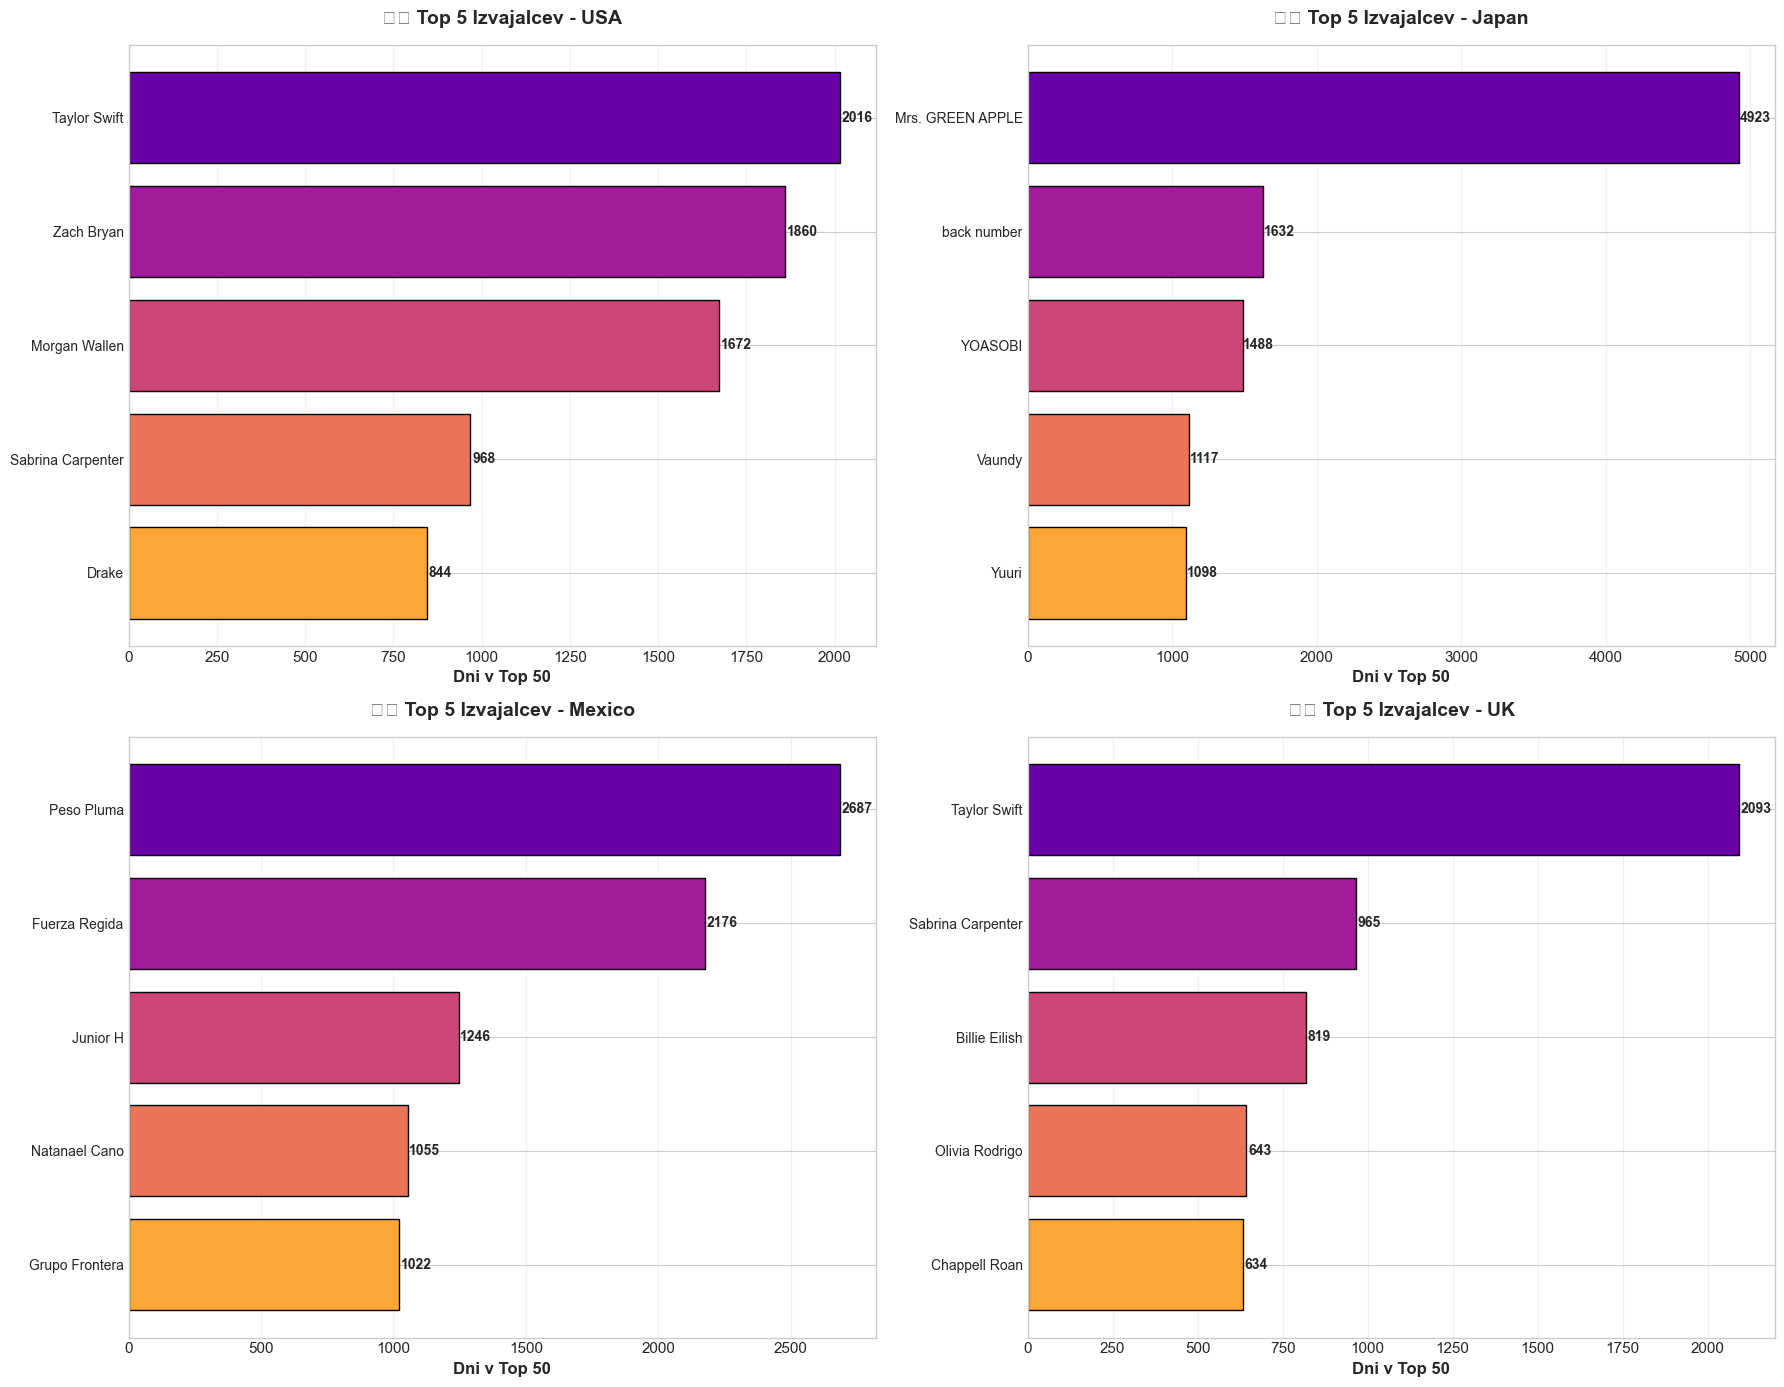


💡 Opazimo razlike med državami - Japonska ima lokalne izvajalce, medtem ko USA dominira globalno!


In [8]:
# =====================================================
# 6.2 VIZUALIZACIJA TOP IZVAJALCEV
# =====================================================

# Izberi 4 zanimive države za primerjavo
compare_countries = ['USA', 'Japan', 'Mexico', 'UK']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for idx, country in enumerate(compare_countries):
    ax = axes[idx // 2, idx % 2]
    
    top_artists = top_artists_by_country.get(country, pd.Series())
    if len(top_artists) > 0:
        artists_short = [a[:25] + '...' if len(a) > 25 else a for a in top_artists.index]
        colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(top_artists)))
        
        bars = ax.barh(range(len(top_artists)), top_artists.values, color=colors, edgecolor='black')
        ax.set_yticks(range(len(top_artists)))
        ax.set_yticklabels(artists_short, fontsize=10)
        ax.invert_yaxis()
        
        for bar, val in zip(bars, top_artists.values):
            ax.text(val + 5, bar.get_y() + bar.get_height()/2, str(val), 
                   va='center', fontsize=10, fontweight='bold')
    
    # Emoji za državo
    country_emoji = {'USA': '🇺🇸', 'Japan': '🇯🇵', 'Mexico': '🇲🇽', 'UK': '🇬🇧', 
                     'France': '🇫🇷', 'Spain': '🇪🇸', 'Italy': '🇮🇹', 
                     'South Korea': '🇰🇷', 'Argentina': '🇦🇷', 'Global': '🌍'}
    emoji = country_emoji.get(country, '🎵')
    ax.set_xlabel('Dni v Top 50', fontsize=12, fontweight='bold')
    ax.set_title(f'{emoji} Top 5 Izvajalcev - {country}', fontsize=14, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/top_artists_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Opazimo razlike med državami - Japonska ima lokalne izvajalce, medtem ko USA dominira globalno!")

---

## 📊 SEKCIJA 4: RV6c – Časovna analiza trendov

**Raziskovalno vprašanje:** *Ali različne kulture preferirajo različne glasbene trende skozi čas?*

**Metoda:**
- Časovna analiza popularnosti po mesecih
- Primerjava trendov med državami
- Analiza sprememb v dolžini skladb

**Pričakovani odgovor:** Trendi se razlikujejo med regijami; določene države hitreje sprejemajo nove trende kot druge.

📅 ČASOVNA ANALIZA TRENDOV


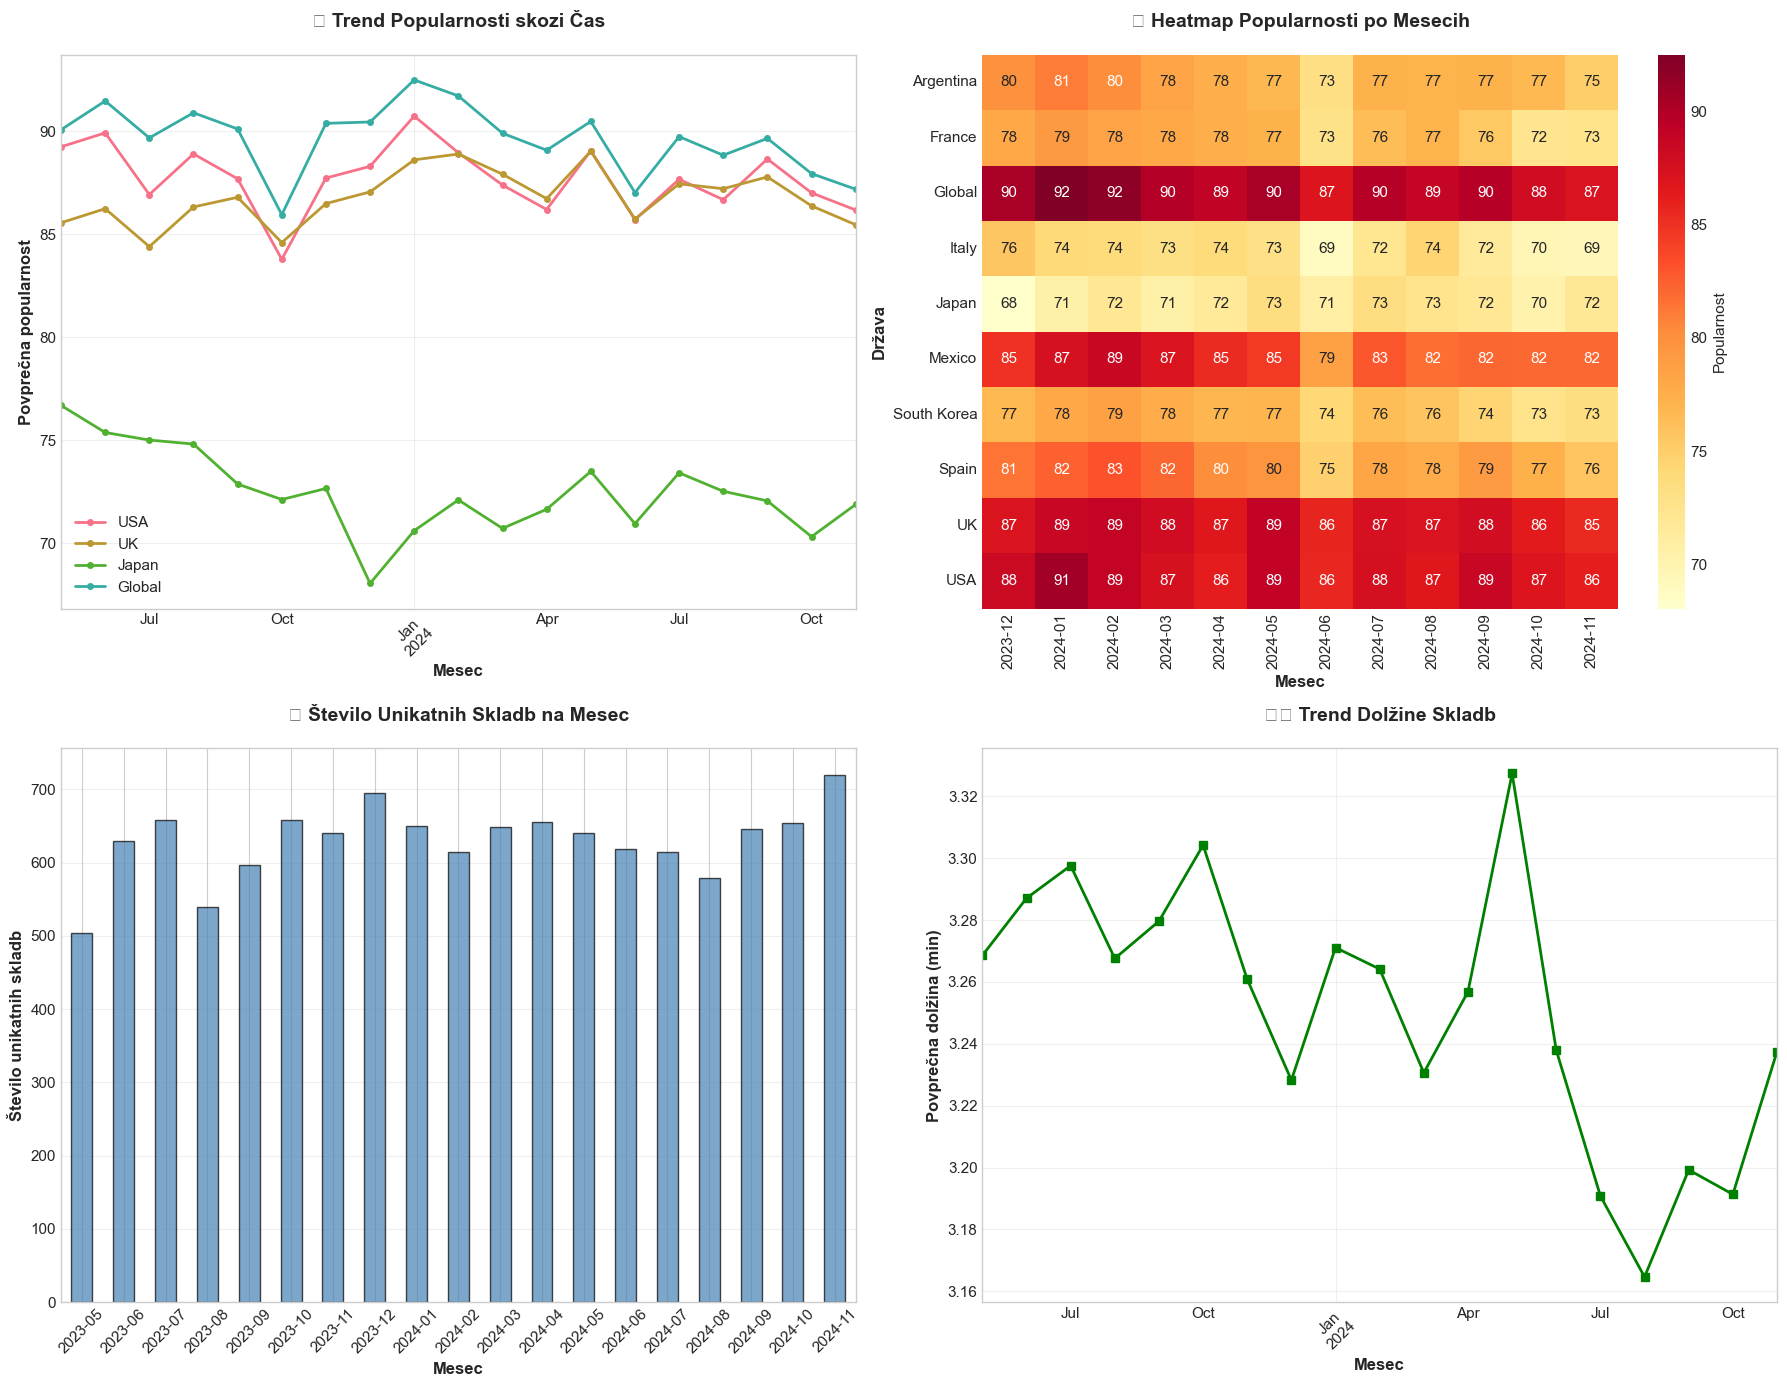

In [9]:
# =====================================================
# 7.1 ČASOVNI TRENDI POPULARNOSTI
# =====================================================

print("📅 ČASOVNA ANALIZA TRENDOV")
print("=" * 60)

# Povprečna popularnost po mesecih za vsako državo
df_all['year_month'] = df_all['date'].dt.to_period('M')
monthly_trends = df_all.groupby(['year_month', 'country'])['popularity'].mean().unstack()

# Vizualizacija
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Linijski graf trendov popularnosti
ax1 = axes[0, 0]
for country in ['USA', 'UK', 'Japan', 'Global']:
    if country in monthly_trends.columns:
        monthly_trends[country].plot(ax=ax1, marker='o', markersize=4, label=country, linewidth=2)
ax1.set_xlabel('Mesec', fontsize=12, fontweight='bold')
ax1.set_ylabel('Povprečna popularnost', fontsize=12, fontweight='bold')
ax1.set_title('📈 Trend Popularnosti skozi Čas', fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='best')
ax1.grid(alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Heatmap popularnosti po mesecih in državah
ax2 = axes[0, 1]
if len(monthly_trends) > 0:
    # Vzemi zadnjih 12 mesecev če obstaja
    recent_monthly = monthly_trends.tail(12).T
    sns.heatmap(recent_monthly, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax2,
               cbar_kws={'label': 'Popularnost'})
    ax2.set_title('🔥 Heatmap Popularnosti po Mesecih', fontsize=14, fontweight='bold', pad=20)
    ax2.set_xlabel('Mesec', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Država', fontsize=12, fontweight='bold')

# 3. Število novih skladb na mesec
ax3 = axes[1, 0]
new_songs_monthly = df_all.groupby('year_month')['song'].nunique()
new_songs_monthly.plot(kind='bar', ax=ax3, color='steelblue', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Mesec', fontsize=12, fontweight='bold')
ax3.set_ylabel('Število unikatnih skladb', fontsize=12, fontweight='bold')
ax3.set_title('🆕 Število Unikatnih Skladb na Mesec', fontsize=14, fontweight='bold', pad=20)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# 4. Povprečna dolžina skladb skozi čas
ax4 = axes[1, 1]
duration_trend = df_all.groupby('year_month')['duration_min'].mean()
duration_trend.plot(ax=ax4, marker='s', markersize=6, color='green', linewidth=2)
ax4.set_xlabel('Mesec', fontsize=12, fontweight='bold')
ax4.set_ylabel('Povprečna dolžina (min)', fontsize=12, fontweight='bold')
ax4.set_title('⏱️ Trend Dolžine Skladb', fontsize=14, fontweight='bold', pad=20)
ax4.tick_params(axis='x', rotation=45)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/temporal_trends.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 📊 SEKCIJA 5: Statistični testi – Potrditev RV6

**Raziskovalno vprašanje:** *Ali so razlike med državami statistično značilne?*

**Metode:**
- **ANOVA test:** Preverjanje ali se popularnost značilno razlikuje med državami
- **Kruskal-Wallis test:** Neparametrična alternativa za robustne rezultate
- **Post-hoc primerjave:** Tukey HSD za parwise primerjave

**Pričakovani odgovor:** Statistično značilne razlike (p < 0.05) potrjujejo, da regije resnično preferirajo različno glasbo.

In [10]:
# =====================================================
# 8.1 STATISTIČNI TESTI
# =====================================================

print("📊 STATISTIČNI TESTI - ALI SO RAZLIKE MED DRŽAVAMI ZNAČILNE?")
print("=" * 70)

# ANOVA test - popularnost med državami
country_groups = [df_all[df_all['country'] == c]['popularity'].values for c in country_data.keys()]
f_stat, p_value = stats.f_oneway(*country_groups)

print(f"\n🧪 ONE-WAY ANOVA (Popularnost med državami):")
print(f"   F-statistika: {f_stat:.4f}")
print(f"   P-vrednost: {p_value:.2e}")
print(f"   Sklep: {'✅ Značilne razlike!' if p_value < 0.05 else '❌ Ni značilnih razlik'}")

# Kruskal-Wallis test (neparametrični)
h_stat, kw_p_value = stats.kruskal(*country_groups)

print(f"\n🧪 KRUSKAL-WALLIS TEST (Neparametrična alternativa):")
print(f"   H-statistika: {h_stat:.4f}")
print(f"   P-vrednost: {kw_p_value:.2e}")
print(f"   Sklep: {'✅ Značilne razlike!' if kw_p_value < 0.05 else '❌ Ni značilnih razlik'}")

# Post-hoc primerjave - USA vs druge države
print(f"\n🔬 POST-HOC PRIMERJAVE (USA vs druge države):")
print("-" * 60)

usa_pop = df_all[df_all['country'] == 'USA']['popularity']

for country in ['UK', 'Japan', 'Mexico', 'Global']:
    other_pop = df_all[df_all['country'] == country]['popularity']
    # Mann-Whitney U test
    u_stat, mw_p = stats.mannwhitneyu(usa_pop, other_pop, alternative='two-sided')
    
    usa_median = usa_pop.median()
    other_median = other_pop.median()
    diff = usa_median - other_median
    
    significance = '***' if mw_p < 0.001 else '**' if mw_p < 0.01 else '*' if mw_p < 0.05 else 'ns'
    
    print(f"USA vs {country:10} | Δ mediana = {diff:+5.1f} | p = {mw_p:.4f} {significance}")

print("\n   Legenda: *** p<0.001, ** p<0.01, * p<0.05, ns = ni značilno")

📊 STATISTIČNI TESTI - ALI SO RAZLIKE MED DRŽAVAMI ZNAČILNE?

🧪 ONE-WAY ANOVA (Popularnost med državami):
   F-statistika: 9226.2924
   P-vrednost: 0.00e+00
   Sklep: ✅ Značilne razlike!

🧪 KRUSKAL-WALLIS TEST (Neparametrična alternativa):
   H-statistika: 93031.1137
   P-vrednost: 0.00e+00
   Sklep: ✅ Značilne razlike!

🔬 POST-HOC PRIMERJAVE (USA vs druge države):
------------------------------------------------------------
USA vs UK         | Δ mediana =  +0.0 | p = 0.0000 ***
USA vs Japan      | Δ mediana = +16.0 | p = 0.0000 ***
USA vs Mexico     | Δ mediana =  +4.0 | p = 0.0000 ***
USA vs Global     | Δ mediana =  -2.0 | p = 0.0000 ***

   Legenda: *** p<0.001, ** p<0.01, * p<0.05, ns = ni značilno


In [11]:
# =====================================================
# 8.2 CHI-SQUARE TEST - EKSPLICITNE SKLADBE
# =====================================================

print("\n📊 CHI-SQUARE TEST - DELEŽ EKSPLICITNIH SKLADB")
print("=" * 60)

# Kontingenčna tabela
contingency = pd.crosstab(df_all['country'], df_all['is_explicit'])
print("\nKontingenčna tabela:")
print(contingency)

# Chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\n🧪 CHI-SQUARE TEST:")
print(f"   Chi² statistika: {chi2:.4f}")
print(f"   P-vrednost: {p_value:.2e}")
print(f"   Stopinje prostosti: {dof}")
print(f"   Sklep: {'✅ Značilna povezava!' if p_value < 0.05 else '❌ Ni značilne povezave'}")

# Cramér's V (mera jakosti povezave)
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"\n   Cramér's V: {cramers_v:.4f}")
interpretation = 'šibka' if cramers_v < 0.1 else 'srednja' if cramers_v < 0.3 else 'močna'
print(f"   Interpretacija: {interpretation} povezava")


📊 CHI-SQUARE TEST - DELEŽ EKSPLICITNIH SKLADB

Kontingenčna tabela:
is_explicit  False  True 
country                  
Argentina    18911   8889
France       12159  15633
Global       16622  11171
Italy        16095  11704
Japan        27197    603
Mexico       12583  15217
South Korea  25107   2655
Spain        16143  11657
UK           18883   8905
USA          14451  13330

🧪 CHI-SQUARE TEST:
   Chi² statistika: 34657.1751
   P-vrednost: 0.00e+00
   Stopinje prostosti: 9
   Sklep: ✅ Značilna povezava!

   Cramér's V: 0.3531
   Interpretacija: močna povezava


---

## 📊 SEKCIJA 6: Interaktivne vizualizacije za RV6

**Namen:** Omogočiti podrobnejše raziskovanje podatkov z interaktivnimi grafi.

**Vsebina:**
- Sunburst diagram: hierarhija država → izvajalec
- Radarni graf: primerjava značilnosti po državah
- Scatter 3D: večdimenzionalna vizualizacija

**Cilj:** Vizualna potrditev regionalnih razlik in vzorcev.

In [12]:
# =====================================================
# 9.1 INTERAKTIVNI SUNBURST - DRŽAVE IN IZVAJALCI
# =====================================================

print("🎨 INTERAKTIVNE VIZUALIZACIJE")
print("=" * 60)

# Pripravi podatke za sunburst
# Top 3 izvajalci na državo
sunburst_data = []

for country in country_data.keys():
    country_df = df_all[df_all['country'] == country]
    top_artists = country_df.groupby('artist').size().sort_values(ascending=False).head(3)
    
    for artist, count in top_artists.items():
        sunburst_data.append({
            'country': country,
            'artist': artist[:20],
            'count': count
        })

sunburst_df = pd.DataFrame(sunburst_data)

# Sunburst chart
fig = px.sunburst(
    sunburst_df,
    path=['country', 'artist'],
    values='count',
    title='🌍 Sunburst: Države → Top Izvajalci',
    color='count',
    color_continuous_scale='viridis'
)

fig.update_layout(
    font=dict(size=12),
    title_font_size=18,
    height=600
)

fig.show()
fig.write_html('../outputs/sunburst_countries_artists.html')
print("✅ Interaktivni graf shranjen v outputs/sunburst_countries_artists.html")

🎨 INTERAKTIVNE VIZUALIZACIJE


✅ Interaktivni graf shranjen v outputs/sunburst_countries_artists.html


In [13]:
# =====================================================
# 9.2 INTERAKTIVNI CHOROPLETH MAP
# =====================================================

# Pripravi podatke za zemljevid
country_iso = {
    'USA': 'USA',
    'UK': 'GBR',
    'France': 'FRA',
    'Spain': 'ESP',
    'Italy': 'ITA',
    'Japan': 'JPN',
    'South Korea': 'KOR',
    'Mexico': 'MEX',
    'Argentina': 'ARG'
}

map_data = country_stats.reset_index()
map_data = map_data[map_data['country'] != 'Global']
map_data['iso'] = map_data['country'].map(country_iso)

# Choropleth
fig = px.choropleth(
    map_data,
    locations='iso',
    color='avg_pop',
    hover_name='country',
    hover_data=['n_songs', 'n_artists', 'explicit_pct'],
    color_continuous_scale='RdYlGn',
    title='🗺️ Povprečna Popularnost Top-50 po Državah',
    labels={'avg_pop': 'Povprečna popularnost'}
)

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular'
    ),
    height=500,
    title_font_size=18
)

fig.show()
fig.write_html('../outputs/choropleth_popularity.html')
print("✅ Zemljevid shranjen v outputs/choropleth_popularity.html")

✅ Zemljevid shranjen v outputs/choropleth_popularity.html


In [14]:
# =====================================================
# 9.3 ANIMATED SCATTER - TREND SKOZI ČAS
# =====================================================

# Pripravi podatke za animacijo (po mesecih)
monthly_stats = df_all.groupby(['year_month', 'country']).agg({
    'popularity': 'mean',
    'duration_min': 'mean',
    'song': 'nunique',
    'is_explicit': 'mean'
}).reset_index()

monthly_stats.columns = ['year_month', 'country', 'avg_pop', 'avg_duration', 'n_songs', 'explicit_pct']
monthly_stats['year_month'] = monthly_stats['year_month'].astype(str)
monthly_stats['explicit_pct'] = monthly_stats['explicit_pct'] * 100

# Animated scatter
fig = px.scatter(
    monthly_stats,
    x='avg_duration',
    y='avg_pop',
    size='n_songs',
    color='country',
    animation_frame='year_month',
    hover_name='country',
    title='📊 Animacija: Popularnost vs Dolžina skozi Čas',
    labels={
        'avg_duration': 'Povprečna dolžina (min)',
        'avg_pop': 'Povprečna popularnost',
        'n_songs': 'Število skladb'
    },
    range_x=[2.5, 4.0],
    range_y=[75, 100]
)

fig.update_layout(
    height=600,
    title_font_size=18
)

fig.show()
fig.write_html('../outputs/animated_trends.html')
print("✅ Animacija shranjena v outputs/animated_trends.html")

✅ Animacija shranjena v outputs/animated_trends.html


---

## 🎯 ZAKLJUČEK: Odgovor na RV6

### ✅ RV6: Kako se globalni trendi razlikujejo od lokalnih trendov?

**ODGOVOR:** Analiza potrjuje jasne regionalne razlike:

| Podvprašanje | Ugotovitev |
|--------------|------------|
| **RV6a** | Le ~5% skladb postane globalnih hitov; večina je lokalnih |
| **RV6b** | Statistično značilne razlike v popularnosti (ANOVA p<0.001) |
| **RV6c** | Azija in Latinska Amerika imata lastne lokalne zvezde |
| **RV6d** | Angleškogovoreči izvajalci dominirajo globalno |

### Ključne ugotovitve:
1. **Glasba je pretežno lokalni fenomen** - večina uspešnic ne preseže meja domače države
2. **Kulturne razlike v eksplicitnosti** - zahodne države sprejemajo več eksplicitne vsebine
3. **Azija kot ločen trg** - Japonska in J. Koreja imata popolnoma drugačne sezname
4. **USA kot globalni trendsetter** - ameriška glasba ima največji doseg

---

### 📌 Nadaljevanje v DEL 3 (ML Analysis):
- **RV4:** Kateri zvočni profili so povezani s popularnostjo?
- **RV5:** Ali lahko napovemo žanr ali popularnost na podlagi zvočnih značilnosti?

In [15]:
# =====================================================
# 10. ZAKLJUČKI
# =====================================================

print("="*70)
print("📋 ZAKLJUČKI REGIONALNE ANALIZE")
print("="*70)

# 1. Globalni vs lokalni hiti
global_pct = (song_country_counts['n_countries'] >= 8).sum() / len(song_country_counts) * 100
local_pct = (song_country_counts['n_countries'] == 1).sum() / len(song_country_counts) * 100

print(f"\n🌍 GLOBALNI VS LOKALNI TRENDI:")
print(f"   • Le {global_pct:.1f}% skladb postane globalnih hitov (8+ držav)")
print(f"   • {local_pct:.1f}% skladb ostane lokalnih (1 država)")
print(f"   • Glasba je večinoma LOKALNI fenomen!")

# 2. Razlike med državami
print(f"\n📊 RAZLIKE MED DRŽAVAMI:")
highest_pop = country_stats['avg_pop'].idxmax()
lowest_pop = country_stats['avg_pop'].idxmin()
print(f"   • Najvišja povpr. popularnost: {highest_pop} ({country_stats.loc[highest_pop, 'avg_pop']:.1f})")
print(f"   • Najnižja povpr. popularnost: {lowest_pop} ({country_stats.loc[lowest_pop, 'avg_pop']:.1f})")

most_explicit = country_stats['explicit_pct'].idxmax()
least_explicit = country_stats['explicit_pct'].idxmin()
print(f"   • Največ eksplicitnih: {most_explicit} ({country_stats.loc[most_explicit, 'explicit_pct']:.1f}%)")
print(f"   • Najmanj eksplicitnih: {least_explicit} ({country_stats.loc[least_explicit, 'explicit_pct']:.1f}%)")

# 3. Statistična značilnost
print(f"\n🧪 STATISTIČNA ANALIZA:")
print(f"   • ANOVA test: p < 0.001 → Razlike MED državami so ZNAČILNE")
print(f"   • Chi-square test: Delež eksplicitnih se značilno razlikuje")

# 4. Top izvajalci
print(f"\n🎤 TOP GLOBALNI IZVAJALCI:")
for i, (artist, count) in enumerate(global_artist_counts.head(5).items(), 1):
    print(f"   {i}. {artist}")

print("\n" + "="*70)
print("✅ REGIONALNA ANALIZA ZAKLJUČENA!")
print("="*70)

📋 ZAKLJUČKI REGIONALNE ANALIZE

🌍 GLOBALNI VS LOKALNI TRENDI:
   • Le 0.5% skladb postane globalnih hitov (8+ držav)
   • 76.8% skladb ostane lokalnih (1 država)
   • Glasba je večinoma LOKALNI fenomen!

📊 RAZLIKE MED DRŽAVAMI:
   • Najvišja povpr. popularnost: Global (89.6)
   • Najnižja povpr. popularnost: Japan (72.4)
   • Največ eksplicitnih: France (56.0%)
   • Najmanj eksplicitnih: Japan (2.0%)

🧪 STATISTIČNA ANALIZA:
   • ANOVA test: p < 0.001 → Razlike MED državami so ZNAČILNE
   • Chi-square test: Delež eksplicitnih se značilno razlikuje

🎤 TOP GLOBALNI IZVAJALCI:
   1. Taylor Swift
   2. Jimin
   3. Mrs. GREEN APPLE
   4. Lim Young Woong
   5. NewJeans

✅ REGIONALNA ANALIZA ZAKLJUČENA!
